广义优势估计（Generalized Advantage Estimation, GAE） 是强化学习（RL）中用于计算优势函数的一种方法，由 John Schulman 等人在 2016 年的论文《High-Dimensional Continuous Control Using Generalized Advantage Estimation》中提出。
- 它是 PPO、TRPO 等主流策略梯度算法的核心组件，<font color='red'>其本质是在偏差（Bias）和方差（Variance）之间寻找一个可控的平衡点。</font>



**偏差（Bias）**与**方差（Variance）**是评估估计量或模型性能的两个核心指标。
- <font color='red'>它们分别衡量了系统性偏离与随机性波动，两者往往此消彼长，共同决定了模型的最终误差。</font>

# 📌 直观理解：打靶比喻
想象你在练习射箭，目标是靶心：
- 低偏差、低方差：所有箭都密集地射在靶心附近（理想状态）
- **高偏差、低方差**：所有箭都密集地射在同一个位置，<font color='red'>但偏离靶心很远（系统性地打偏了）</font>
- 低偏差、高方差：箭的落点很分散，但平均位置在靶心附近（每次都不一样，但没系统性偏差）
- 高偏差、高方差：箭又分散又偏离靶心（最差情况）

# 📐 数学定义
假设我们要估计一个真实值 θ ，用估计量$\hat{θ}$来近似它。

## 偏差（Bias）
偏差衡量的是估计量的**期望值**与<font color='red'>真实值</font>之间的差距：

Bias($\hat{θ}$)=E[$\hat{θ}$]−<font color='red'>θ</font>

- 偏差为 0 → 估计量是无偏的（unbiased），<font color='blue'>长期来看平均能打中靶心</font>
- 偏差不为 0 → <font color='red'>估计量是有偏的（biased），存在系统性偏离</font>

## 方差（Variance）
方差衡量的是<font color='red'>估计量在不同样本下的**波动程度**：</font>

Var($\hat{θ}$)=E[  ($\hat{θ}$−$E[\hat{θ}])^2 ]$
- 方差大 → **每次估计的结果差异很大，不稳定**
- 方差小 → 每次估计的结果都很接近，稳定

## 🔗 偏差-方差分解（Bias-Variance Decomposition）
在机器学习中，我们最关心的是**均方误差（MSE）**，<font color='red'>它可以被优雅地分解为偏差和方差两部分（加上不可约误差）：</font>

MSE=$E[(y− \hat{f}(x))^2]=Bias^2+Variance+Irreducible Error$


其中：
- Bias2=$(E[\hat{f}(x)]−f(x))^2$：模型预测的期望与真实函数的差距
- Variance=$E[( \hat{f}​(x)−E[ \hat{f}(x)])^2]$：**模型在不同训练集上的预测波动**
- Irreducible Error ：<font color='blue'>数据本身的噪声，任何模型都无法消除</font>

### 核心洞察：
- 总误差 = 偏差² + 方差 + 噪声。我们无法消除噪声，但可以通过调节模型来平衡偏差和方差。

## ⚖️ 偏差-方差权衡（Bias-Variance Tradeoff）
这是机器学习中最核心的概念之一：

| | 高偏差（欠拟合） | 高方差（过拟合） |
|---|---|---|
| 表现 | 训练集和测试集表现都差 | 训练集表现好，测试集表现差 |
| 原因 | 模型太简单，无法捕捉数据规律 | 模型太复杂，把噪声也学进去了 |
| 例子 | 用直线拟合曲线数据 | 用高阶多项式完美穿过每个训练点 |
| 解决方向 | 增加模型复杂度 | 正则化、增加数据、降低复杂度 |

直觉理解：
- 模型越简单 → 偏差高（<font color='blue'>学不到复杂模式</font>），方差低（对数据变化不敏感）
- 模型越复杂 → 偏差低（<font color='blue'>能拟合复杂模式</font>），方差高（<font color='red'>对训练数据的微小变化过度敏感</font>）
目标：找到那个"甜蜜点"，使偏差² + 方差 的总和最小。

# 🎯 在强化学习中的体现（以 GAE 为例）
回到你之前问的 GAE，偏差-方差权衡在那里有非常具体的体现：

| 估计方法 | 偏差 | 方差 | 原因 |
|---|---|---|---|
| 单步 TD（ $ \lambda=0 $ ） | 高 | 低 | 依赖  $ V(s) $  的近似，但只受一步随机性影响 |
| 蒙特卡洛（ $ \lambda=1 $ ） | 低（无偏） | 高 | <font color='red'>用真实回报，但整条轨迹的随机性都累积进来</font> |
| GAE（$0<\lambda<1 $ ） | 中等 | 中等 | 通过  $ \lambda $  在两者之间平滑插值 |

- 高偏差： V(s) 本身是近似的，用它来截断会引入系统性误差
- 高方差：实际采样到的奖励和状态转移具有随机性，<font color='blue'>轨迹越长，累积的随机性越大</font>
- GAE 的 <font color='blue'>λ 参数本质上就是一个偏差-方差调节旋钮</font>

## 🛠️ 实践中如何管理偏差和方差
- 降低偏差：使用更强的模型、更多特征、更长的训练时间、更少的正则化
- **降低方差：正则化（L1/L2）、Dropout、集成学习（Bagging）、增加训练数据、早停（Early Stopping）**
- 同时改善两者：集成学习（Boosting 降偏差，Bagging 降方差）、<font color='blue'>交叉验证选择最优复杂度</font>

## 📝 总结
- 偏差：你的估计"平均来看偏了多少"——系统性的不准确
- 方差：你的估计<font color='red'>"每次波动有多大"</font>——随机性的不稳定
- **总误差 = 偏差² + 方差 + 噪声，三者共同决定了模型的上限**
- <font color='blue'>几乎所有机器学习方法的核心挑战，都是在偏差和方差之间找到最佳平衡</font>

In [5]:
from IPython.display import Image

# 🛠️ 正则化如何降低方差
## 核心直觉
正则化的本质是限制模型的复杂度，使其不能随意拟合训练数据中的噪声。这直接降低了模型对不同训练集的敏感度，即降低了方差。

## 以 L2 正则化（Ridge 回归）为例

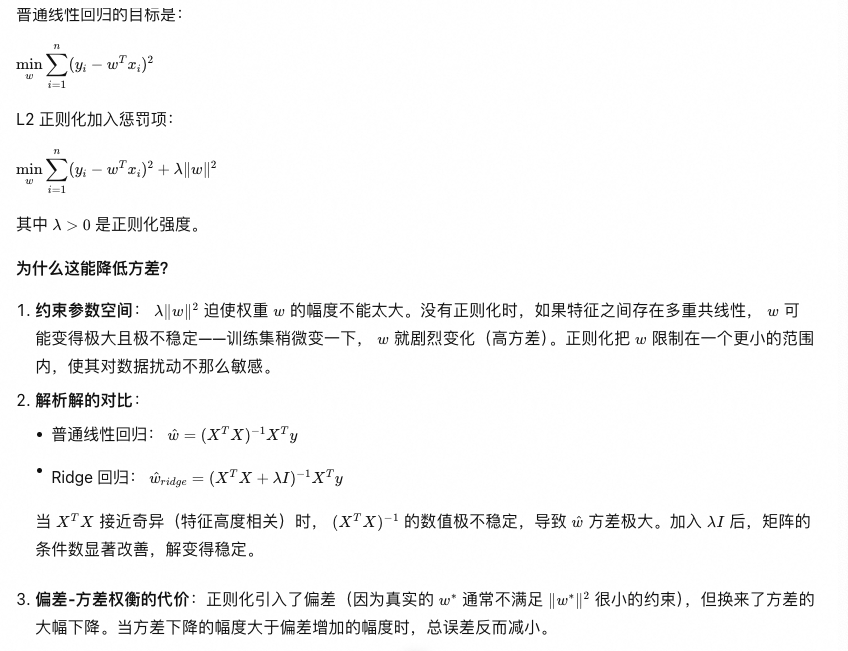

In [6]:
Image(filename='./Image/l2_norm.png')

## 从偏差-方差分解的角度理解
正则化强度 λ 从 0 逐渐增大时：

|  $ \lambda $  | 偏差 | 方差 | 总误差 |
|---|---|---|---|
| 0（无正则化） | 低 | 高 | 可能高（过拟合） |
| 适中 | 略增 | 显著降低 | 最低（最优） |
| 过大 | 很高 | 很低 | 高（欠拟合） |

最优的 λ 就是让 Bias^2 + Variance之和最小的那个点。

### 其他正则化方式的类似逻辑
- L1 正则化（Lasso）：
  - 通过 $λ∥w∥_1$产生稀疏解，等效于做特征选择，降低模型复杂度 → 降方差
- Dropout（神经网络）：
  - 训练时随机丢弃神经元，等效于对指数级数量的子网络做集成平均 → 降方差
- 早停（Early Stopping）：
  - 限制训练轮数，防止模型过度拟合训练数据 → 降方差
- 数据增强：
  - 等效于增加训练数据量，使模型对特定样本的依赖减弱 → 降方差
  
## 📝 总结
- 偏差-方差分解：
  - 对于平方损失，总误差严格等于 噪声+$偏差^2$+方差，三者各司其职
- 正则化降方差的本质：
  - 通过约束模型复杂度，使模型对训练数据的随机波动不那么敏感，代价是引入一定的偏差
- 最优正则化强度：
  - 不是越大越好，而是找到偏差和方差之和最小的平衡点 

# 📌 前置知识：什么是优势函数
在策略梯度方法中，我们希望提高那些"比平均水平更好"的动作的概率，降低"比平均水平更差"的动作的概率。
- <font color='blue'>这个"比平均水平好多少"的度量就是优势函数：</font>

$A(s_t,a_t)=Q(s_t,a_t)−V(s_t)$
- $Q(s_t,a_t)$：在状态 st采取动作 at后的期望回报
- $V(s_t)$ ：在状态 st下的期望回报（状态价值）

  - 优势为正 → 这个动作比平均好，应该增加其概率；
  - 优势为负 → 应该降低其概率。
问题在于： <font color='blue'>Q 和 V 都是未知的，我们需要从采样数据中**估计它们**</font>

# 🔍 从蒙特卡洛到 TD：偏差-方差困境

要估计优势，最直接的思路是看"实际回报"减去"基线"。
- <font color='red'>根据我们**向前看多少步**，会产生不同的估计器</font>：

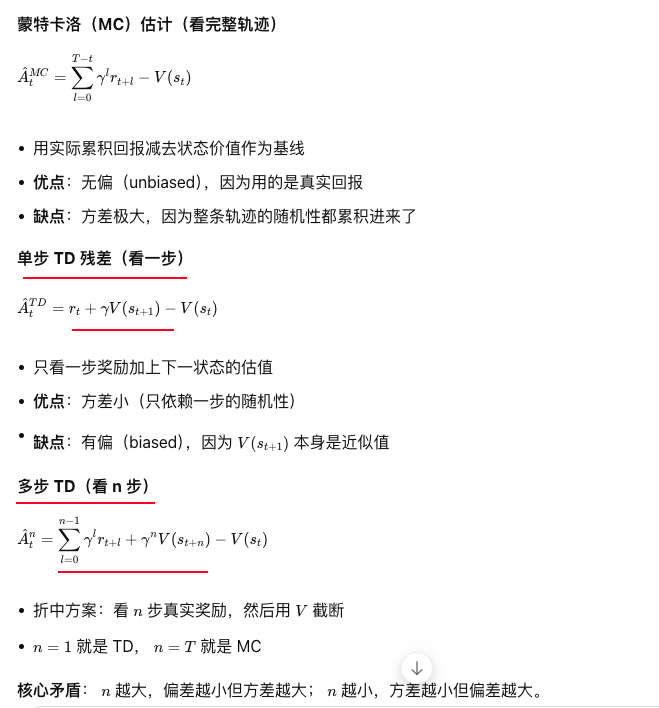

In [3]:
Image(filename='./Image/td.png')

# 💡 GAE 的核心思想
GAE 的巧妙之处在于：<font color='red'>它不是简单地选一个固定的 n ，而是对所有 n 步估计做指数加权平均。</font>

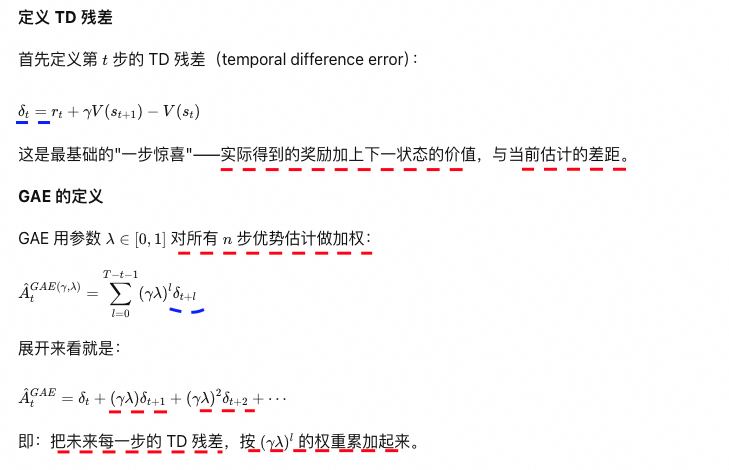

In [7]:
Image(filename='./Image/gae.png')

它可以重写为递归形式：

$\hat{A_t} = δ_t + (γλ) ⋅  \hat{A_{t+1}}$

 
这意味着：<font color='red'>计算第 t  步的 GAE，必须先知道第 t+1  步的 GAE。</font>
- 这是一个从后往前的递推链。

## 具体数值例子

假设一条轨迹有 3 步（T=3 ，t=0,1,2 ），**参数 γ=0.9,λ=0.95** 。

### 场景设定

| 时间步 | 奖励 r_t | 价值 V(s_t) | 下一状态价值 V(s_{t+1}) |
| --- | -------- | ----------- | ------------------- |
| t=0 | 1        | 10          | 12                  |
| t=1 | 2        | 12          | 15                  |
| t=2 | 3        | 15          | 0（终止状态）             |


#### 第一步：计算 TD 误差 $δ_t$

$δ_t = r_t + λV(s_{t+1}) - V(s_t)$

- $δ_0$=1+0.9×12−10=1.8 
- $δ_1$=2+0.9×15−12=3.5 
- $δ_2$=3+0.9×0−15=−12 

#### 正向展开（理论公式）

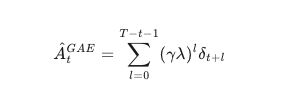

In [9]:
Image(filename='./Image/gae2.png')

- $\hat{A_{t+2}}$ = $δ_2$ = -12 最后一步，没有未来）
- $\hat{A_{t+1}}$ = $δ_1$ + 0.855 × $δ_2$=3.5+0.855 × (−12)=−6.76 
- $\hat{A_{t+0}}$ = $δ_0 + 0.855 × δ_1 + 0.855^2 × δ_2$=1.8 + 0.855 × 3.5 + 0.731 × (−12)=−3.98 

#### 第三步：代码反向计算（递归实现）

In [ ]:
last_gae = 0  # 边界条件：A_T = 0

# t=2（最后一步）
gae = δ₂ + γλ × last_gae = -12 + 0.855 × 0 = -12
last_gae = -12

# t=1
gae = δ₁ + γλ × last_gae = 3.5 + 0.855 × (-12) = -6.76
last_gae = -6.76

# t=0
gae = δ₀ + γλ × last_gae = 1.8 + 0.855 × (-6.76) = -3.98
last_gae = -3.98

结果完全一致：[-3.98, -6.76, -12]

| 要点       | 说明                                                         |
| -------- | ---------------------------------------------------------- |
| **递归关系** | $\hat{A}_t = \delta_t + \gamma\lambda \cdot \hat{A}_{t+1}$ |
| **依赖方向** | 前向依赖后向（$t$ 依赖 $t+1$）                                       |
| **计算顺序** | 必须从后往前（`reversed`）                                         |
| **边界条件** | 最后一步的 `last_gae = 0`                                       |
| **代码本质** | 用动态规划 $O(T)$ 时间计算，避免重复展开幂级数                                |


# 🎛️ λ 的作用：一个旋钮控制偏差-方差

λ（lambda） 是 GAE 最关键的超参数，<font color='red'>它直接控制偏差与方差的权衡</font>：

|  λ  值 | 等价于 | 特点 |
|---|---|---|
|  λ = 0   | 单步 TD | 方差最小，偏差最大 |
|  λ = 1   | 蒙特卡洛 | 无偏，方差最大 |
| 0 < λ < 1   | 指数加权的 n 步平均 | 在偏差和方差之间平滑过渡 |

直觉理解：
- λ 接近 0 → 只信任最近一步的 TD 残差，快速截断 → 低方差、高偏差
- λ 接近 1 → 把未来很多步的 TD 残差都纳入 → 低偏差、高方差
- <font color='red'>实践中通常取 λ=0.95 ，这是一个在大多数任务上表现良好的经验值</font>

# ⚙️ 实际计算方式
GAE 有一个非常优雅的递推形式，可以从后往前高效计算：

$\hat{A_t}=δ_t+γλ \hat{A_{t+1}}$
 
其中 $δ_t=r_t+γV(s_{t+1})−V(s_t)$
从轨迹的最后一个时间步开始，倒序计算即可得到每个时间步的优势估计。

## 伪代码：

In [ ]:
# 假设已收集一条轨迹 (s_0, a_0, r_0), (s_1, a_1, r_1), ..., (s_T, a_T, r_T)
# 以及价值函数 V

advantages = []
last_gae = 0

for t in reversed(range(T)):
    delta = r[t] + gamma * V(s[t+1]) - V(s[t])
    gae = delta + gamma * lambda * last_gae
    advantages.insert(0, gae)
    last_gae = gae

# 📊 为什么 GAE 如此重要
- 偏差-方差可控：
  - <font color='red'>通过调节 λ ，可以在不同任务中找到最佳平衡点</font>
- 计算高效：
  - 递推形式使得计算复杂度为 O(T)
- 降低方差效果显著：
  - <font color='red'>相比纯蒙特卡洛，GAE 大幅降低了策略梯度估计的方差，使训练更稳定</font>
- 广泛验证：
  - 在 PPO、TRPO、A2C/A3C 等算法中，GAE 已成为标准配置，在 Atari 游戏、机器人控制、大语言模型对齐（RLHF）等任务中表现优异
  
  
# 📝  GAE 的本质是：
- 用指数衰减的权重，<font color='red'>将不同长度的 n 步优势估计融合成一个统一的估计量</font>。**它不追求完全无偏**（那是蒙特卡洛），**也不追求完全低方差**（那是单步 TD），而是通过 λ 这个旋钮，让使用者根据具体任务灵活地找到最优的偏差-方差平衡点。
- <font color='red'>这也是它在现代强化学习中成为"标配"的根本原因。</font>
